
# LangGraph Multi-Agent Architecture

## Features
- Supervisor / Researcher / Writer Agents
- Groq Llama 3.3 70B
- Tavily Search
- MemorySaver Checkpointing
- Human-in-the-loop Breakpoint
- Mermaid Diagram Generation
- Streamlit Deployment Example
- Voice Emotion Detection Extension


In [10]:

import operator
from typing import Annotated, List, TypedDict, Literal
from pydantic import BaseModel, Field

class AgentState(TypedDict):
    task: str
    research_notes: Annotated[List[str], operator.add]
    draft: str
    next_node: str
    retry_count: int
    revision_feedback: str

class Router(BaseModel):
    next_worker: Literal["researcher", "writer", "FINISH"] = Field(description="Next node")
    instructions: str = Field(description="Instructions")
    is_critical: bool = Field(description="Human review required")


In [ ]:

from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
import os

# Replace with your keys
os.environ["GROQ_API_KEY"] = "YOUR_GROQ_API_KEY"
os.environ["TAVILY_API_KEY"] = "YOUR_TAVILY_API_KEY"

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0
)

search_tool = TavilySearchResults(k=2)


ModuleNotFoundError: No module named 'langchain_groq'

In [3]:

def researcher(state: AgentState):
    print("🚀 Researcher is digging...")

    results = search_tool.invoke(state["task"])

    return {
        "research_notes": [str(results)],
        "retry_count": 0
    }

def writer(state: AgentState):
    print("✍️ Writer is composing...")

    context = "\n".join(state["research_notes"])

    response = llm.invoke(
        f"Write a report on {state['task']} using: {context}"
    )

    return {"draft": response.content}

def supervisor(state: AgentState):
    print("🧠 Supervisor is reviewing state...")

    structured_llm = llm.with_structured_output(Router)

    prompt = f'''
    Task: {state['task']}
    Notes collected: {len(state['research_notes'])}
    Current Draft: {state['draft'][:100]}

    Rules:
    1. No notes -> researcher
    2. Notes available and no draft -> writer
    3. Draft exists -> FINISH
    '''

    decision = structured_llm.invoke(prompt)

    return {
        "next_node": decision.next_worker,
        "revision_feedback": decision.instructions
    }


In [4]:

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(AgentState)

builder.add_node("supervisor", supervisor)
builder.add_node("researcher", researcher)
builder.add_node("writer", writer)

builder.set_entry_point("supervisor")

builder.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {
        "researcher": "researcher",
        "writer": "writer",
        "FINISH": END
    }
)

builder.add_edge("researcher", "supervisor")
builder.add_edge("writer", "supervisor")

memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory,
    interrupt_before=["writer"]
)


## Extension Task 1: LangGraph Diagram

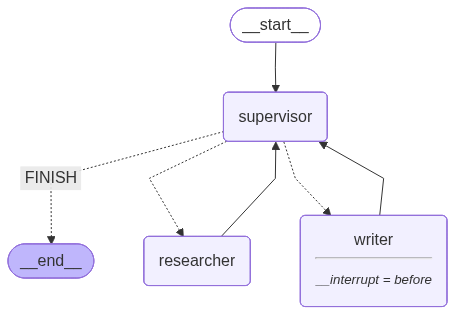

Diagram saved successfully


In [5]:

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

with open("multi_agent_architecture.png", "wb") as f:
    f.write(graph.get_graph().draw_mermaid_png())

print("Diagram saved successfully")


In [6]:

print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	researcher(researcher)
	writer(writer<hr/><small><em>__interrupt = before</em></small>)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	researcher --> supervisor;
	supervisor -. &nbsp;FINISH&nbsp; .-> __end__;
	supervisor -.-> researcher;
	supervisor -.-> writer;
	writer --> supervisor;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [7]:

config = {
    "configurable": {
        "thread_id": "workshop_user_1"
    }
}

initial_input = {
    "task": "Impact of LPU architecture on AI inference speeds",
    "research_notes": [],
    "retry_count": 0,
    "draft": "",
    "next_node": "",
    "revision_feedback": ""
}

for event in graph.stream(
    initial_input,
    config,
    stream_mode="values"
):
    print(event)

snapshot = graph.get_state(config)

if snapshot.next:

    print("Paused:", snapshot.next)

    for event in graph.stream(
        None,
        config,
        stream_mode="values"
    ):
        print(event)


{'task': 'Impact of LPU architecture on AI inference speeds', 'research_notes': [], 'draft': '', 'next_node': '', 'retry_count': 0, 'revision_feedback': ''}
🧠 Supervisor is reviewing state...


NameError: name 'llm' is not defined


# Extension Task 2

## Deploy on Streamlit and Adapt Researcher–Writer Pattern for Voice Emotion Detection



### Architecture

Supervisor → Emotion Detector → Researcher → Writer → END

- Emotion Detector extracts emotion from audio.
- Researcher gathers context and supporting information.
- Writer generates final report.
- Streamlit provides UI.


In [8]:

# Emotion Detection Example

from transformers import pipeline

emotion_model = pipeline(
    "audio-classification",
    model="superb/wav2vec2-base-superb-er"
)

# result = emotion_model('sample.wav')
# print(result)


c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\configuration_utils.py:364: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of the model checkpoint at superb/wav2vec2-base-superb-er were not used when initializing Wav2Vec2ForSequenceClassification: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing Wav2Vec2Fo

In [9]:

# Streamlit Example

streamlit_code = '''
import streamlit as st

st.title("Voice Emotion Detection using LangGraph")

uploaded_audio = st.file_uploader(
    "Upload Audio",
    type=["wav","mp3"]
)

if uploaded_audio:
    st.audio(uploaded_audio)

    if st.button("Analyze"):
        st.success("Run LangGraph workflow here")
'''

print(streamlit_code)



import streamlit as st

st.title("Voice Emotion Detection using LangGraph")

uploaded_audio = st.file_uploader(
    "Upload Audio",
    type=["wav","mp3"]
)

if uploaded_audio:
    st.audio(uploaded_audio)

    if st.button("Analyze"):
        st.success("Run LangGraph workflow here")




### Required Packages

```bash
pip install langgraph
pip install langchain
pip install langchain-groq
pip install langchain-community
pip install tavily-python
pip install streamlit
pip install transformers
pip install torch
pip install librosa
pip install speechrecognition
```


In [ ]:
!pip install streamlit
!pip install langgraph
!pip install langchain
!pip install langchain-groq
!pip install langchain-community
!pip install tavily-python
!pip install transformers
!pip install torch
!pip install librosa
!pip install soundfile
!pip install python-dotenv

In [ ]:
streamlit_app = '''
import os
import tempfile
import operator

import streamlit as st

from dotenv import load_dotenv
from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field

from transformers import pipeline

from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults

from langgraph.graph import StateGraph, END

load_dotenv()

# -----------------------------
# LLM + SEARCH
# -----------------------------

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0
)

search_tool = TavilySearchResults(k=2)

emotion_model = pipeline(
    "audio-classification",
    model="superb/wav2vec2-base-superb-er"
)

# -----------------------------
# STATE
# -----------------------------

class AgentState(TypedDict):
    task: str
    audio_path: str
    emotion: str
    research_notes: Annotated[List[str], operator.add]
    draft: str
    next_node: str

# -----------------------------
# ROUTER
# -----------------------------

class Router(BaseModel):

    next_worker: Literal[
        "emotion_detector",
        "researcher",
        "writer",
        "FINISH"
    ]

    instructions: str

# -----------------------------
# EMOTION DETECTOR
# -----------------------------

def emotion_detector(state):

    result = emotion_model(
        state["audio_path"]
    )

    return {
        "emotion": result[0]["label"]
    }

# -----------------------------
# RESEARCHER
# -----------------------------

def researcher(state):

    query = f"""
    Explain emotion:
    {state['emotion']}
    """

    results = search_tool.invoke(query)

    return {
        "research_notes": [str(results)]
    }

# -----------------------------
# WRITER
# -----------------------------

def writer(state):

    notes = "\\n".join(
        state["research_notes"]
    )

    prompt = f"""
    Generate a report.

    Emotion:
    {state['emotion']}

    Research:
    {notes}
    """

    report = llm.invoke(prompt)

    return {
        "draft": report.content
    }

# -----------------------------
# SUPERVISOR
# -----------------------------

def supervisor(state):

    structured_llm = llm.with_structured_output(
        Router
    )

    prompt = f"""
    Emotion:
    {state.get('emotion','')}

    Notes:
    {len(state['research_notes'])}

    Draft:
    {state['draft']}

    Routing Rules:

    No emotion ->
    emotion_detector

    Emotion but no notes ->
    researcher

    Notes but no draft ->
    writer

    Draft exists ->
    FINISH
    """

    decision = structured_llm.invoke(
        prompt
    )

    return {
        "next_node": decision.next_worker
    }

# -----------------------------
# GRAPH
# -----------------------------

builder = StateGraph(
    AgentState
)

builder.add_node(
    "supervisor",
    supervisor
)

builder.add_node(
    "emotion_detector",
    emotion_detector
)

builder.add_node(
    "researcher",
    researcher
)

builder.add_node(
    "writer",
    writer
)

builder.set_entry_point(
    "supervisor"
)

builder.add_conditional_edges(
    "supervisor",
    lambda x: x["next_node"],
    {
        "emotion_detector":
        "emotion_detector",

        "researcher":
        "researcher",

        "writer":
        "writer",

        "FINISH":
        END
    }
)

builder.add_edge(
    "emotion_detector",
    "supervisor"
)

builder.add_edge(
    "researcher",
    "supervisor"
)

builder.add_edge(
    "writer",
    "supervisor"
)

graph = builder.compile()

# -----------------------------
# STREAMLIT UI
# -----------------------------

st.title(
    "Voice Emotion Detection using LangGraph"
)

audio_file = st.file_uploader(
    "Upload WAV File",
    type=["wav"]
)

if audio_file:

    st.audio(audio_file)

    with tempfile.NamedTemporaryFile(
        delete=False,
        suffix=".wav"
    ) as temp_file:

        temp_file.write(
            audio_file.read()
        )

        path = temp_file.name

    if st.button(
        "Analyze Emotion"
    ):

        result = graph.invoke(
            {
                "task":
                "Voice Emotion Detection",

                "audio_path":
                path,

                "emotion":
                "",

                "research_notes":
                [],

                "draft":
                "",

                "next_node":
                ""
            }
        )

        st.success(
            "Analysis Complete"
        )

        st.subheader(
            "Detected Emotion"
        )

        st.write(
            result["emotion"]
        )

        st.subheader(
            "Generated Report"
        )

        st.write(
            result["draft"]
        )
'''

with open("app.py", "w") as f:
    f.write(streamlit_app)

print("app.py created successfully")

In [ ]:
env_text = """
GROQ_API_KEY=Groq_API_Key_Here
TAVILY_API_KEY=Tavily_API_Key_Here
"""

with open(".env", "w") as f:
    f.write(env_text)

print(".env created")

In [ ]:
!streamlit run app.py

In [1]:
print("""
User Upload Audio
        |
        v
Supervisor
        |
        v
Emotion Detector
        |
        v
Researcher (Tavily Search)
        |
        v
Writer (Groq LLM)
        |
        v
Final Emotion Report
""")


User Upload Audio
        |
        v
Supervisor
        |
        v
Emotion Detector
        |
        v
Researcher (Tavily Search)
        |
        v
Writer (Groq LLM)
        |
        v
Final Emotion Report

